# [가설검증] 서울 아파트는 정말 매년 1억 원씩 오를까?

기준연월을 입력하고 아래 코드 셀을 실행하세요. KB 서울 아파트 월간 매매가격지수로 최근 10·20·30년의 명목 누적 상승률과 연평균 상승률을 계산합니다.

기간,시작,종료,누적 상승률,연평균 상승률
최근 10년,2016.7,2026.7,86.2%,6.4%
최근 20년,2006.7,2026.7,129.6%,4.2%
최근 30년,1996.7,2026.7,408.2%,5.6%


기간,시작,종료,누적 상승률,연평균 상승률,현재 가격 기준 연 상승액
최근 10년,2016.7,2026.7,128.6%,8.6%,1억 996만원
전체 17년 7개월,2008.12,2026.7,165.3%,5.7%,"7,281만원"


KB 자료 업데이트일: **2026년 08월 10일**

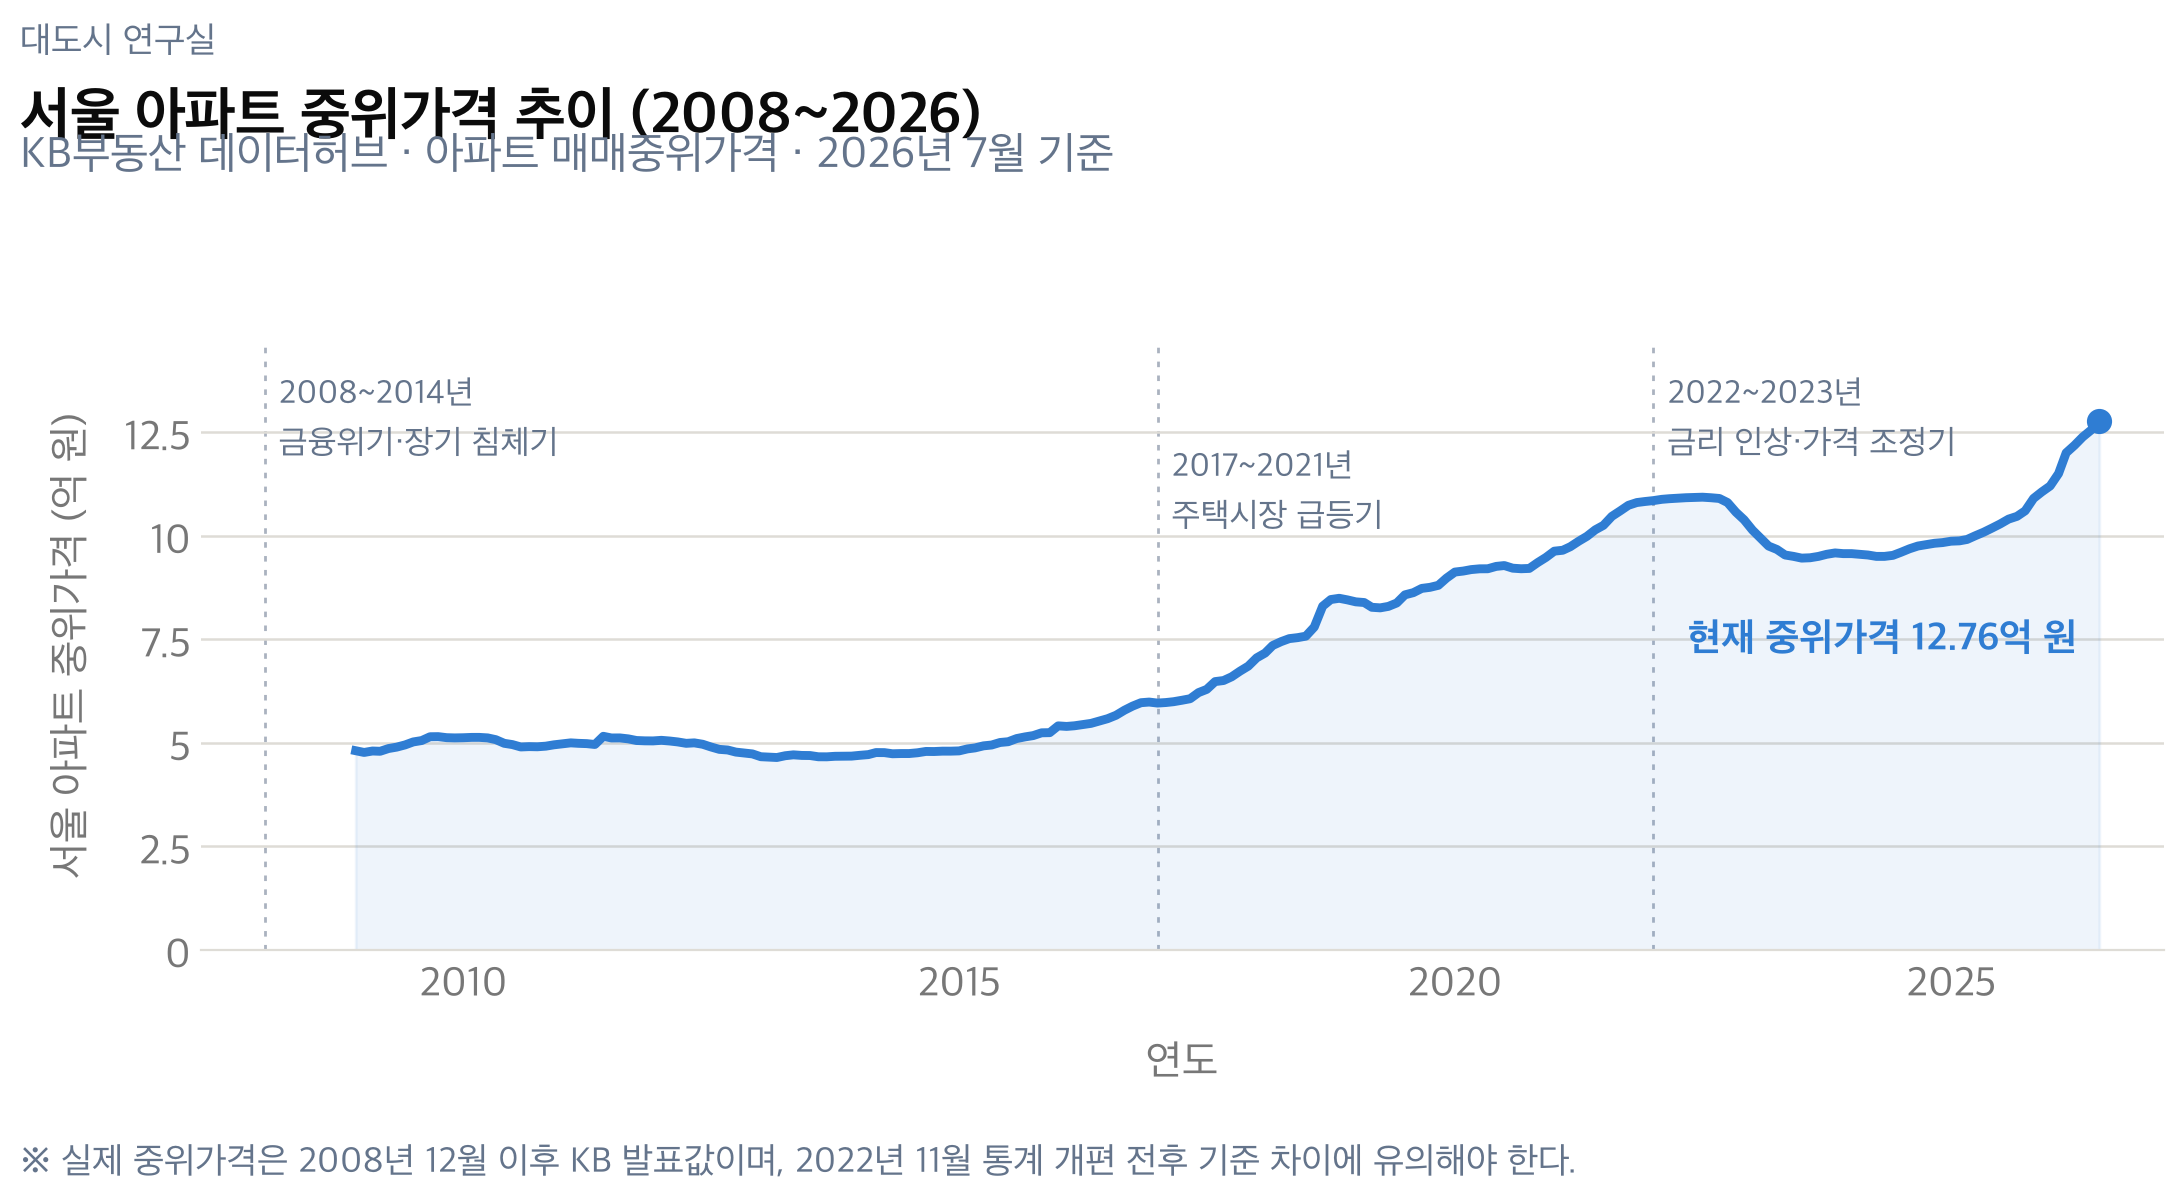

[KB 매매가격지수 원자료](https://data.kbland.kr/kbstats/wmh?tIdx=HT01&tsIdx=monthAptMonthSalePriceInx) · [KB 매매중위가격 원자료](https://data.kbland.kr/kbstats/wmh?tIdx=HT10&tsIdx=aptSaleMedianPrice)

/Users/1111429/src/daedosee-lab/va_apt_seoul_1eok/output/seoul_apartment_price_growth_summary.csv

/Users/1111429/src/daedosee-lab/va_apt_seoul_1eok/output/seoul_apartment_median_price_growth_summary.csv

/Users/1111429/src/daedosee-lab/va_apt_seoul_1eok/output/seoul_apartment_median_price.png

In [11]:
# @title 서울 아파트 장기 상승률 기준을 입력하고 실행하세요
기준연도 = 2026  # @param {type:"integer", min:1986, step:1}
기준월 = 7  # @param {type:"integer", min:1, max:12, step:1}

"""KB 서울 아파트 월간 매매가격지수의 장기 명목 상승률을 계산한다.

KB부동산 데이터허브 주택가격동향조사의 월간 아파트 매매가격지수
전체 시계열을 사용한다. 누적 상승률은 종료 지수를 시작 지수로 나눈
수익률이며, 연평균 상승률은 같은 월 사이의 CAGR이다. 물가상승률은
차감하지 않는다.
"""

import json
import os
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import matplotlib
matplotlib.use("Agg")
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager
import pandas as pd
from IPython.display import FileLink, HTML, Image, Markdown, display


IS_COLAB = bool(os.environ.get("COLAB_RELEASE_TAG")) or Path("/content").exists()
OUTPUT_DIR = Path("/content/output") if IS_COLAB else Path("output")
END_YEAR = int(기준연도)
END_MONTH = int(기준월)
END_PERIOD = pd.Period(year=END_YEAR, month=END_MONTH, freq="M")
PERIOD_YEARS = (10, 20, 30)
SEOUL_REGION_CODE = "1100000000"
KB_API_URL = (
    "https://data-api.kbland.kr/bfmstat/weekMnthlyHuseTrnd/"
    "priceIndexOnlyMonthAptExcel"
)
KB_MEDIAN_API_URL = (
    "https://data-api.kbland.kr/bfmstat/weekMnthlyHuseTrnd/mdpsPrc"
)
KB_SOURCE_URL = (
    "https://data.kbland.kr/kbstats/wmh?"
    "tIdx=HT01&tsIdx=monthAptMonthSalePriceInx"
)
KB_MEDIAN_SOURCE_URL = (
    "https://data.kbland.kr/kbstats/wmh?"
    "tIdx=HT10&tsIdx=aptSaleMedianPrice"
)
BACKGROUND_COLOR = "#FFFFFF"
TEXT_COLOR = "#0B0B0B"
SECONDARY_TEXT_COLOR = "#64748B"
PRICE_COLOR = "#2F7DD3"
GRID_COLOR = "#DEDCD6"
TICK_COLOR = "#777777"
BRAND_SIZE = 13
TITLE_SIZE = 21
SUBTITLE_SIZE = 16
FOOTNOTE_SIZE = 13
FONT_CANDIDATES = (
    "Pretendard",
    "Apple SD Gothic Neo",
    "Noto Sans CJK KR",
    "Malgun Gothic",
)


def validate_parameters() -> None:
    """기준연월과 분석 기간을 검증한다."""
    if not 1 <= END_MONTH <= 12:
        raise ValueError("기준월은 1~12월이어야 합니다.")
    earliest_period = END_PERIOD - max(PERIOD_YEARS) * 12
    if earliest_period < pd.Period("1986-01", freq="M"):
        raise ValueError(
            "최근 30년 계산을 위해 기준연월은 2016년 1월 이후여야 합니다."
        )


def download_seoul_apartment_index() -> tuple[pd.Series, str]:
    """KB에서 서울 아파트 월간 매매가격지수 전체 시계열을 받는다."""
    params = {
        "매매전세코드": "01",
        "월간주간구분코드": "01",
        "매물종별구분": "01",
        "지역코드": "",
        "type": "false",
    }
    request = Request(
        f"{KB_API_URL}?{urlencode(params)}",
        headers={
            "osType": "HUB",
            "User-Agent": "Mozilla/5.0",
            "Referer": "https://data.kbland.kr/",
        },
    )
    with urlopen(request, timeout=60) as response:
        payload = json.load(response)
    header = payload.get("dataHeader", {})
    if header.get("resultCode") != "10000":
        raise RuntimeError(
            f"KB 가격지수를 받지 못했습니다: {header.get('message', '알 수 없는 오류')}"
        )
    body = payload["dataBody"]["data"]
    seoul = next(
        (
            row for row in body["데이터리스트"]
            if row["지역코드"] == SEOUL_REGION_CODE
        ),
        None,
    )
    if seoul is None:
        raise RuntimeError("KB 가격지수에서 서울 자료를 찾지 못했습니다.")
    dates = pd.PeriodIndex(
        [item["기준날짜"] for item in seoul["dataList"]],
        freq="M",
    )
    values = pd.to_numeric(
        [item["데이터"] for item in seoul["dataList"]],
        errors="coerce",
    )
    series = pd.Series(values, index=dates, name="price_index").dropna()
    return series, str(body["업데이트일자"])


def download_seoul_median_price_history() -> pd.Series:
    """KB에서 서울 아파트 매매중위가격 전체 시계열을 받는다."""
    params = {
        "매매전세코드": "01",
        "매물종별구분": "01",
        "지역코드": "",
    }
    request = Request(
        f"{KB_MEDIAN_API_URL}?{urlencode(params)}",
        headers={
            "osType": "HUB",
            "User-Agent": "Mozilla/5.0",
            "Referer": "https://data.kbland.kr/",
        },
    )
    with urlopen(request, timeout=60) as response:
        payload = json.load(response)
    header = payload.get("dataHeader", {})
    if header.get("resultCode") != "10000":
        raise RuntimeError(
            f"KB 중위가격을 받지 못했습니다: {header.get('message', '알 수 없는 오류')}"
        )
    body = payload["dataBody"]["data"]
    seoul = next(
        (
            row for row in body["데이터리스트"]
            if row["지역코드"] == SEOUL_REGION_CODE
        ),
        None,
    )
    if seoul is None:
        raise RuntimeError("KB 중위가격에서 서울 자료를 찾지 못했습니다.")
    dates = pd.PeriodIndex(body["날짜리스트"], freq="M")
    values = pd.Series(
        pd.to_numeric(seoul["dataList"], errors="coerce"),
        index=dates,
    ).dropna()
    if END_PERIOD not in values.index:
        raise RuntimeError(f"{END_PERIOD} 서울 아파트 중위가격이 없습니다.")
    return values * 10_000


def calculate_growth_summary(price_index: pd.Series) -> pd.DataFrame:
    """최근 10·20·30년의 누적 상승률과 CAGR을 계산한다."""
    if END_PERIOD not in price_index.index:
        latest = price_index.index.max()
        raise RuntimeError(
            f"{END_PERIOD} 지수가 없습니다. 최신 자료는 {latest}입니다."
        )
    rows = []
    ending_index = float(price_index.loc[END_PERIOD])
    for years in PERIOD_YEARS:
        start_period = END_PERIOD - years * 12
        if start_period not in price_index.index:
            raise RuntimeError(f"{start_period} 지수가 없습니다.")
        starting_index = float(price_index.loc[start_period])
        growth_multiple = ending_index / starting_index
        rows.append({
            "period_years": years,
            "period_label": f"최근 {years}년",
            "start_period": str(start_period),
            "end_period": str(END_PERIOD),
            "starting_index": starting_index,
            "ending_index": ending_index,
            "cumulative_return": growth_multiple - 1,
            "cagr": growth_multiple ** (1 / years) - 1,
        })
    return pd.DataFrame(rows)


def calculate_median_growth_summary(
    median_price_history: pd.Series,
) -> pd.DataFrame:
    """실제 중위가격의 최근 10년과 전체 기간 상승률을 계산한다."""
    available = median_price_history.loc[:END_PERIOD].dropna()
    ten_year_start = END_PERIOD - 10 * 12
    if ten_year_start not in available.index:
        raise RuntimeError(f"{ten_year_start} 서울 아파트 중위가격이 없습니다.")
    periods = (
        ("최근 10년", ten_year_start),
        (None, available.index.min()),
    )
    ending_price = float(available.loc[END_PERIOD])
    rows = []
    for period_label, start_period in periods:
        elapsed_months = (
            (END_PERIOD.year - start_period.year) * 12
            + END_PERIOD.month - start_period.month
        )
        elapsed_years = elapsed_months / 12
        elapsed_years_int, remaining_months = divmod(elapsed_months, 12)
        display_label = (
            period_label
            if period_label is not None
            else f"전체 {elapsed_years_int}년 {remaining_months}개월"
        )
        starting_price = float(available.loc[start_period])
        growth_multiple = ending_price / starting_price
        rows.append({
            "period_label": display_label,
            "start_period": str(start_period),
            "end_period": str(END_PERIOD),
            "starting_price_krw": starting_price,
            "ending_price_krw": ending_price,
            "elapsed_months": elapsed_months,
            "cumulative_return": growth_multiple - 1,
            "cagr": growth_multiple ** (1 / elapsed_years) - 1,
        })
    return pd.DataFrame(rows)


def format_period(period_text: str) -> str:
    """YYYY-MM 형식을 YYYY.M 형식으로 바꾼다."""
    year, month = period_text.split("-")
    return f"{year}.{int(month)}"


def format_annual_increase(amount_krw: float) -> str:
    """연 상승액을 억·만원 단위로 표시한다."""
    amount_manwon = round(amount_krw / 10_000)
    eok, manwon = divmod(amount_manwon, 10_000)
    if eok and manwon:
        return f"{eok}억 {manwon:,}만원"
    if eok:
        return f"{eok}억원"
    return f"{manwon:,}만원"


def display_table(
    summary: pd.DataFrame, current_median_price_krw: float,
    include_annual_increase: bool = True,
) -> pd.DataFrame:
    """HTML 표에 사용할 한글 표시용 데이터를 만든다."""
    table = pd.DataFrame({
        "기간": summary["period_label"],
        "시작": summary["start_period"].map(format_period),
        "종료": summary["end_period"].map(format_period),
        "누적 상승률": summary["cumulative_return"].map("{:.1%}".format),
        "연평균 상승률": summary["cagr"].map("{:.1%}".format),
    })
    if include_annual_increase:
        table["현재 가격 기준 연 상승액"] = (
            summary["cagr"] * current_median_price_krw
        ).map(format_annual_increase)
    return table


def configure_korean_font() -> None:
    """사용 가능한 한글 글꼴을 Matplotlib에 설정한다."""
    installed = {font.name for font in font_manager.fontManager.ttflist}
    font_name = next(
        (name for name in FONT_CANDIDATES if name in installed),
        None,
    )
    if font_name:
        plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False


def save_median_price_chart(
    median_price_history: pd.Series, current_median_price_krw: float,
    output_path: Path,
) -> None:
    """KB 서울 아파트 실제 중위가격 추이를 저장한다."""
    configure_korean_font()
    actual_prices = median_price_history.loc[:END_PERIOD].dropna()
    dates = actual_prices.index.to_timestamp()
    prices_eok = actual_prices / 100_000_000
    start_period = actual_prices.index.min()
    fig, ax = plt.subplots(figsize=(11.5, 6.2))
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_facecolor(BACKGROUND_COLOR)
    ax.plot(
        dates, prices_eok, color=PRICE_COLOR, linewidth=3.2,
        zorder=3,
    )
    ax.fill_between(
        dates, prices_eok, color=PRICE_COLOR, alpha=0.08, zorder=2
    )
    market_phases = (
        ("2008-01-01", "2008~2014년\n금융위기·장기 침체기", 0.96, "left"),
        ("2017-01-01", "2017~2021년\n주택시장 급등기", 0.84, "left"),
        ("2022-01-01", "2022~2023년\n금리 인상·가격 조정기", 0.96, "left"),
    )
    for phase_date, phase_label, label_y, alignment in market_phases:
        phase_timestamp = pd.Timestamp(phase_date)
        ax.axvline(
            phase_timestamp, color=SECONDARY_TEXT_COLOR, linewidth=1.0,
            linestyle=(0, (2, 3)), alpha=0.55, zorder=1,
        )
        offset = -5 if alignment == "right" else 5
        ax.annotate(
            phase_label, xy=(phase_timestamp, label_y),
            xycoords=("data", "axes fraction"),
            xytext=(offset, 0), textcoords="offset points",
            ha=alignment, va="top", fontsize=FOOTNOTE_SIZE - 1,
            linespacing=1.25,
            color=SECONDARY_TEXT_COLOR,
        )
    final_date = dates[-1]
    final_price_eok = float(prices_eok.iloc[-1])
    ax.scatter(
        final_date, final_price_eok, color=PRICE_COLOR, s=65, zorder=4
    )
    ax.annotate(
        f"현재 중위가격 {final_price_eok:.2f}억 원",
        xy=(final_date, 7.5), xytext=(-8, 0),
        textcoords="offset points", ha="right", va="center",
        fontsize=14, fontweight="bold", color=PRICE_COLOR,
    )
    fig.text(
        0.025, 0.975, "대도시 연구실", ha="left", va="top",
        fontsize=BRAND_SIZE, color=SECONDARY_TEXT_COLOR,
    )
    fig.suptitle(
        f"서울 아파트 중위가격 추이 ({start_period.year}~{END_YEAR})",
        x=0.025, y=0.925, ha="left", fontsize=TITLE_SIZE,
        fontweight="bold", color=TEXT_COLOR,
    )
    fig.text(
        0.025, 0.855,
        "KB부동산 데이터허브 · 아파트 매매중위가격 · "
        f"{END_YEAR}년 {END_MONTH}월 기준",
        ha="left", fontsize=SUBTITLE_SIZE, color=SECONDARY_TEXT_COLOR,
    )
    ax.set_xlabel("연도", fontsize=15, color=TICK_COLOR, labelpad=10)
    ax.set_ylabel(
        "서울 아파트 중위가격 (억 원)",
        fontsize=15, color=TICK_COLOR, labelpad=10,
    )
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:g}"))
    ax.tick_params(
        axis="both", colors=TICK_COLOR, labelsize=15, length=0
    )
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.set_ylim(0, float(prices_eok.max()) * 1.15)
    ax.margins(x=0.035)
    fig.text(
        0.025, 0.045,
        f"※ 실제 중위가격은 {start_period.year}년 "
        f"{start_period.month}월 이후 KB 발표값이며, "
        "2022년 11월 통계 개편 전후 기준 차이에 유의해야 한다.",
        fontsize=FOOTNOTE_SIZE, color=SECONDARY_TEXT_COLOR, ha="left",
    )
    fig.tight_layout(rect=(0.035, 0.09, 0.97, 0.82))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        output_path, dpi=200, bbox_inches="tight",
        facecolor=BACKGROUND_COLOR,
    )
    plt.close(fig)


def table_html(
    table: pd.DataFrame, title: str, subtitle: str, notes: list[str]
) -> str:
    """노트북 화면에 표시할 표 HTML을 만든다."""
    html = table.to_html(
        index=False, border=0,
        classes=f"result-table columns-{len(table.columns)}",
        escape=False,
    )
    notes_html = "<br>".join(f"※ {note}" for note in notes)
    return f"""
    <style>
    .apt-result-section{{max-width:700px;margin:0 0 28px;
      font-family:Pretendard,-apple-system,BlinkMacSystemFont,
      "Segoe UI",sans-serif}}
    .result-brand{{margin:0 0 5px;color:#64748b;font-size:13px}}
    .result-title{{margin:0 0 4px;color:#0f172a;font-size:20px;
      font-weight:700}}
    .result-subtitle{{margin:0 0 14px;color:#64748b;font-size:13px}}
    .result-table-wrap{{overflow:hidden;border:1px solid #f0f2f5;
      border-radius:12px}}
    .result-table{{width:100%;table-layout:fixed;
      border-collapse:separate;border-spacing:0;font-size:13px;
      font-variant-numeric:tabular-nums;color:#1e293b}}
    .result-table th{{padding:11px 3px;background:#2b4a75;color:white;
      font-weight:700;line-height:1.35;text-align:center;
      word-break:keep-all}}
    .result-table td{{padding:11px 3px;border-bottom:1px solid #f0f2f5;
      line-height:1.45;text-align:center;white-space:nowrap}}
    .result-table tbody tr:nth-child(even) td{{background:#fafbfc}}
    .result-table tbody tr:last-child td{{border-bottom:0}}
    .result-table td:first-child{{font-weight:700}}
    .columns-5 th:nth-child(1){{width:16%}}
    .columns-5 th:nth-child(2),.columns-5 th:nth-child(3){{width:14%}}
    .columns-5 th:nth-child(4),.columns-5 th:nth-child(5){{width:28%}}
    .columns-6 th:nth-child(1){{width:13%}}
    .columns-6 th:nth-child(2),.columns-6 th:nth-child(3){{width:12%}}
    .columns-6 th:nth-child(4){{width:17%}}
    .columns-6 th:nth-child(5){{width:18%}}
    .columns-6 th:nth-child(6){{width:28%}}
    .result-table td:nth-child(n+4){{text-align:right;padding-right:8px}}
    .result-notes{{margin:10px 0 0;color:#64748b;font-size:13px;
      line-height:1.5}}
    </style><section class="apt-result-section">
      <p class="result-brand">대도시 연구실</p>
      <h2 class="result-title">{title}</h2>
      <p class="result-subtitle">{subtitle}</p>
      <div class="result-table-wrap">{html}</div>
      <p class="result-notes">{notes_html}</p>
    </section>
    """


def save_results(
    summary: pd.DataFrame, median_summary: pd.DataFrame,
    median_price_history: pd.Series, current_median_price_krw: float,
) -> tuple[Path, Path, Path]:
    """상승률 CSV와 실제 중위가격 추이 PNG를 저장한다."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    csv_path = OUTPUT_DIR / "seoul_apartment_price_growth_summary.csv"
    median_csv_path = (
        OUTPUT_DIR / "seoul_apartment_median_price_growth_summary.csv"
    )
    median_chart_path = OUTPUT_DIR / "seoul_apartment_median_price.png"
    summary.to_csv(csv_path, index=False, encoding="utf-8-sig")
    median_summary.to_csv(
        median_csv_path, index=False, encoding="utf-8-sig"
    )
    save_median_price_chart(
        median_price_history, current_median_price_krw, median_chart_path
    )
    return csv_path, median_csv_path, median_chart_path


def display_results(
    table: pd.DataFrame, median_table: pd.DataFrame,
    median_summary: pd.DataFrame, current_median_price_krw: float,
    update_date: str, paths: tuple[Path, Path, Path],
) -> None:
    """자료 기준일, 결과표와 저장 파일을 표시한다."""
    update_label = pd.to_datetime(update_date).strftime("%Y년 %m월 %d일")
    annual_increase_note = (
        f"연 상승액은 {END_YEAR}년 {END_MONTH}월 서울 아파트 중위가격 "
        f"{current_median_price_krw / 100_000_000:.2f}억 원에 각 기간의 "
        "연평균 상승률을 적용한 단순 환산값이다."
    )
    display(HTML(table_html(
        table,
        "서울 아파트 지수 기준 상승률 | 최근 10·20·30년",
        f"KB 월간 아파트 매매가격지수 · {END_YEAR}년 {END_MONTH}월 기준 · 명목",
        [
            "누적 상승률=(종료지수÷시작지수)-1 · 연평균 상승률=CAGR",
            "물가상승률을 차감하지 않은 명목 기준 · "
            "2022년 11월 통계개편 유의",
        ],
    )))
    display(HTML(table_html(
        median_table,
        "서울 아파트 중위가격 상승률 | 최근 10년·전체 기간",
        f"KB 서울 아파트 매매중위가격 · {END_YEAR}년 {END_MONTH}월 기준 · 명목",
        [
            "실제 중위가격 발표값 기준 · 전체 기간은 2008년 12월부터",
            "연평균 상승률은 정확한 월수 기준 CAGR · "
            "2022년 11월 통계개편 유의",
            annual_increase_note,
        ],
    )))
    display(Markdown(f"KB 자료 업데이트일: **{update_label}**"))
    display(Image(filename=str(paths[2])))
    display(Markdown(
        f"[KB 매매가격지수 원자료]({KB_SOURCE_URL}) · "
        f"[KB 매매중위가격 원자료]({KB_MEDIAN_SOURCE_URL})"
    ))
    if not IS_COLAB:
        for path in paths:
            display(FileLink(str(path)))


def main() -> None:
    """입력 검증부터 데이터 수집, 계산, 저장과 출력까지 실행한다."""
    validate_parameters()
    price_index, update_date = download_seoul_apartment_index()
    median_price_history = download_seoul_median_price_history()
    current_median_price_krw = float(median_price_history.loc[END_PERIOD])
    summary = calculate_growth_summary(price_index)
    median_summary = calculate_median_growth_summary(
        median_price_history
    )
    table = display_table(
        summary, current_median_price_krw, include_annual_increase=False
    )
    median_table = display_table(
        median_summary, current_median_price_krw
    )
    paths = save_results(
        summary, median_summary, median_price_history,
        current_median_price_krw,
    )
    display_results(
        table, median_table, median_summary,
        current_median_price_krw, update_date, paths
    )


main()
